# Autoencoder: Federated vs Centralized Learning Analysis (All Data)

This notebook compares autoencoder anomaly detection using:
- **Centralized Learning:** Model trained on all data (normal + anomalous)
- **Federated Learning:** Models trained locally, aggregated globally

**Note:** Both models are trained on all data (including anomalies).

In [78]:
# --- Main Configuration Cell ---
DATA_CONFIG = {
    'output_dir': 'data',
    'num_aircraft': 5,
    'num_anomalous_aircraft': 1,
    'flight_duration_hours': 4,
    'points_per_hour': 60,
    'sensor_names': ['engine_rpm', 'fuel_flow', 'engine_temperature', 'vibration_level']
}

MODEL_CONFIG = {
    'input_dim': len(DATA_CONFIG['sensor_names']),
    'hidden_dim': 32,
    'latent_dim': 8
}

TRAINING_CONFIG = {
    'centralized_epochs': 50,
    'federated_rounds': 10,
    'federated_local_epochs': 5,
    'learning_rate': 0.001,
}

print("✅ Configuration loaded.")

✅ Configuration loaded.


In [79]:
import os
import shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler

from anomfl.data_generation.aircraft_data_generator import Fleet
from anomfl.autoencoders.autoencoder import Autoencoder
from anomfl.federated.centralized_server import FederatedClient, CentralizedServer

print("Libraries imported.")

Libraries imported.


In [80]:
# --- Fixed Scaling Import ---
from anomfl.utils import get_aircraft_scaler, scale_aircraft_data
print("✅ Fixed scaling utilities imported")


✅ Fixed scaling utilities imported


In [81]:
print("--- Starting Data Generation ---")

if os.path.exists(DATA_CONFIG['output_dir']):
    shutil.rmtree(DATA_CONFIG['output_dir'])

FLEET_ID = 1
num_points = DATA_CONFIG['flight_duration_hours'] * DATA_CONFIG['points_per_hour']
interval_minutes = 60 // DATA_CONFIG['points_per_hour']

fleet = Fleet(
    fleet_id=FLEET_ID,
    num_aircraft=DATA_CONFIG['num_aircraft'],
    num_anomalous=DATA_CONFIG['num_anomalous_aircraft'],
    num_points=num_points,
    interval_minutes=interval_minutes
)
fleet.generate_fleet_data(output_dir=DATA_CONFIG['output_dir'])

anomalous_ids = {record['aircraft_id'] for record in fleet.anomaly_records}
file_paths = []
for aircraft in fleet.aircraft_list:
    suffix = "_anomalous.csv" if aircraft.id in anomalous_ids else "_normal.csv"
    path = os.path.join(DATA_CONFIG['output_dir'], f"fleet_{FLEET_ID}", f"aircraft_{FLEET_ID}_{aircraft.id}{suffix}")
    file_paths.append(path)

print(f"✅ Data generation complete.")

--- Starting Data Generation ---
Dataset saved as d:\DL\FL\AnomFL\examples\data\fleet_1\aircraft_1_1_normal.csv
Aircraft 1-1 generated (Normal)
Dataset saved as d:\DL\FL\AnomFL\examples\data\fleet_1\aircraft_1_2_normal.csv
Aircraft 1-2 generated (Normal)
Dataset saved as d:\DL\FL\AnomFL\examples\data\fleet_1\aircraft_1_3_anomalous.csv
Aircraft 1-3 generated (Anomalous)
Dataset saved as d:\DL\FL\AnomFL\examples\data\fleet_1\aircraft_1_4_normal.csv
Aircraft 1-4 generated (Normal)
Dataset saved as d:\DL\FL\AnomFL\examples\data\fleet_1\aircraft_1_5_normal.csv
Aircraft 1-5 generated (Normal)
Anomaly summary saved as d:\DL\FL\AnomFL\examples\data\fleet_1\fleet_1_anomalies.csv
✅ Data generation complete.


In [82]:
print("--- Training Centralized Model (ALL DATA) ---")

all_file_paths = file_paths
print(f"Loading data from {len(all_file_paths)} aircraft files:")
for i, path in enumerate(all_file_paths):
    print(f"  Aircraft {i+1}: {os.path.basename(path)}")

all_dfs = [pd.read_csv(path) for path in all_file_paths]
all_data_df = pd.concat(all_dfs, ignore_index=True)
sensor_data = all_data_df[DATA_CONFIG['sensor_names']]
scaler = get_aircraft_scaler(include_anomalies=True)  # Fixed scaling
scaled_data = scaler.transform(sensor_data)
train_tensor = torch.tensor(scaled_data, dtype=torch.float32)

centralized_model = Autoencoder(
    input_dim=MODEL_CONFIG['input_dim'],
    hidden_dim=MODEL_CONFIG['hidden_dim'],
    latent_dim=MODEL_CONFIG['latent_dim']
)
centralized_model.train_on_tensor(
    train_tensor,
    num_epochs=TRAINING_CONFIG['centralized_epochs'],
    lr=TRAINING_CONFIG['learning_rate']
)

centralized_model.eval()
with torch.no_grad():
    reconstructed = centralized_model(train_tensor)
    final_loss = nn.MSELoss()(reconstructed, train_tensor)
print(f"Final MSE on All Training Data (Centralized): {final_loss.item():.8f}")

--- Training Centralized Model (ALL DATA) ---
Loading data from 5 aircraft files:
  Aircraft 1: aircraft_1_1_normal.csv
  Aircraft 2: aircraft_1_2_normal.csv
  Aircraft 3: aircraft_1_3_anomalous.csv
  Aircraft 4: aircraft_1_4_normal.csv
  Aircraft 5: aircraft_1_5_normal.csv
Starting training...
  Epoch [10/50], Loss: 0.000553
  Epoch [20/50], Loss: 0.000945
  Epoch [30/50], Loss: 0.000912
  Epoch [40/50], Loss: 0.000503
  Epoch [50/50], Loss: 0.000340
Final MSE on All Training Data (Centralized): 0.00051211


In [83]:
print("--- Training Federated Model ---")

clients = [
    FederatedClient(client_id=i + 1, file_path=file_paths[i])
    for i in range(DATA_CONFIG['num_aircraft'])
]
base_model = Autoencoder(
    input_dim=MODEL_CONFIG['input_dim'],
    hidden_dim=MODEL_CONFIG['hidden_dim'],
    latent_dim=MODEL_CONFIG['latent_dim']
)
server = CentralizedServer(clients=clients, model=base_model)
server.train(
    rounds=TRAINING_CONFIG['federated_rounds'],
    local_epochs=TRAINING_CONFIG['federated_local_epochs'],
    lr=TRAINING_CONFIG['learning_rate']
)
federated_model = server.global_model

federated_model.eval()
with torch.no_grad():
    reconstructed = federated_model(train_tensor)
    final_loss = nn.MSELoss()(reconstructed, train_tensor)
print(f"Final MSE on All Training Data (Federated): {final_loss.item():.8f}")

--- Training Federated Model ---

ROUND 1/10
  -> Training Client 1...
    Epoch [2/5], Client Loss: 0.023558
    Epoch [4/5], Client Loss: 0.024894
  -> Training Client 2...
    Epoch [2/5], Client Loss: 0.029585
    Epoch [4/5], Client Loss: 0.029917
  -> Training Client 3...
    Epoch [2/5], Client Loss: 0.059365
    Epoch [4/5], Client Loss: 0.054656
  -> Training Client 4...
    Epoch [2/5], Client Loss: 0.038370
    Epoch [4/5], Client Loss: 0.035333
  -> Training Client 5...
    Epoch [2/5], Client Loss: 0.034751
    Epoch [4/5], Client Loss: 0.041835

ROUND 2/10
  -> Training Client 1...
    Epoch [2/5], Client Loss: 0.033969
    Epoch [4/5], Client Loss: 0.033600
  -> Training Client 2...
    Epoch [2/5], Client Loss: 0.027109
    Epoch [4/5], Client Loss: 0.032805
  -> Training Client 3...
    Epoch [2/5], Client Loss: 0.057867
    Epoch [4/5], Client Loss: 0.040788
  -> Training Client 4...
    Epoch [2/5], Client Loss: 0.023313
    Epoch [4/5], Client Loss: 0.038104
  -> Tr

--- Generating Comparison Plots ---


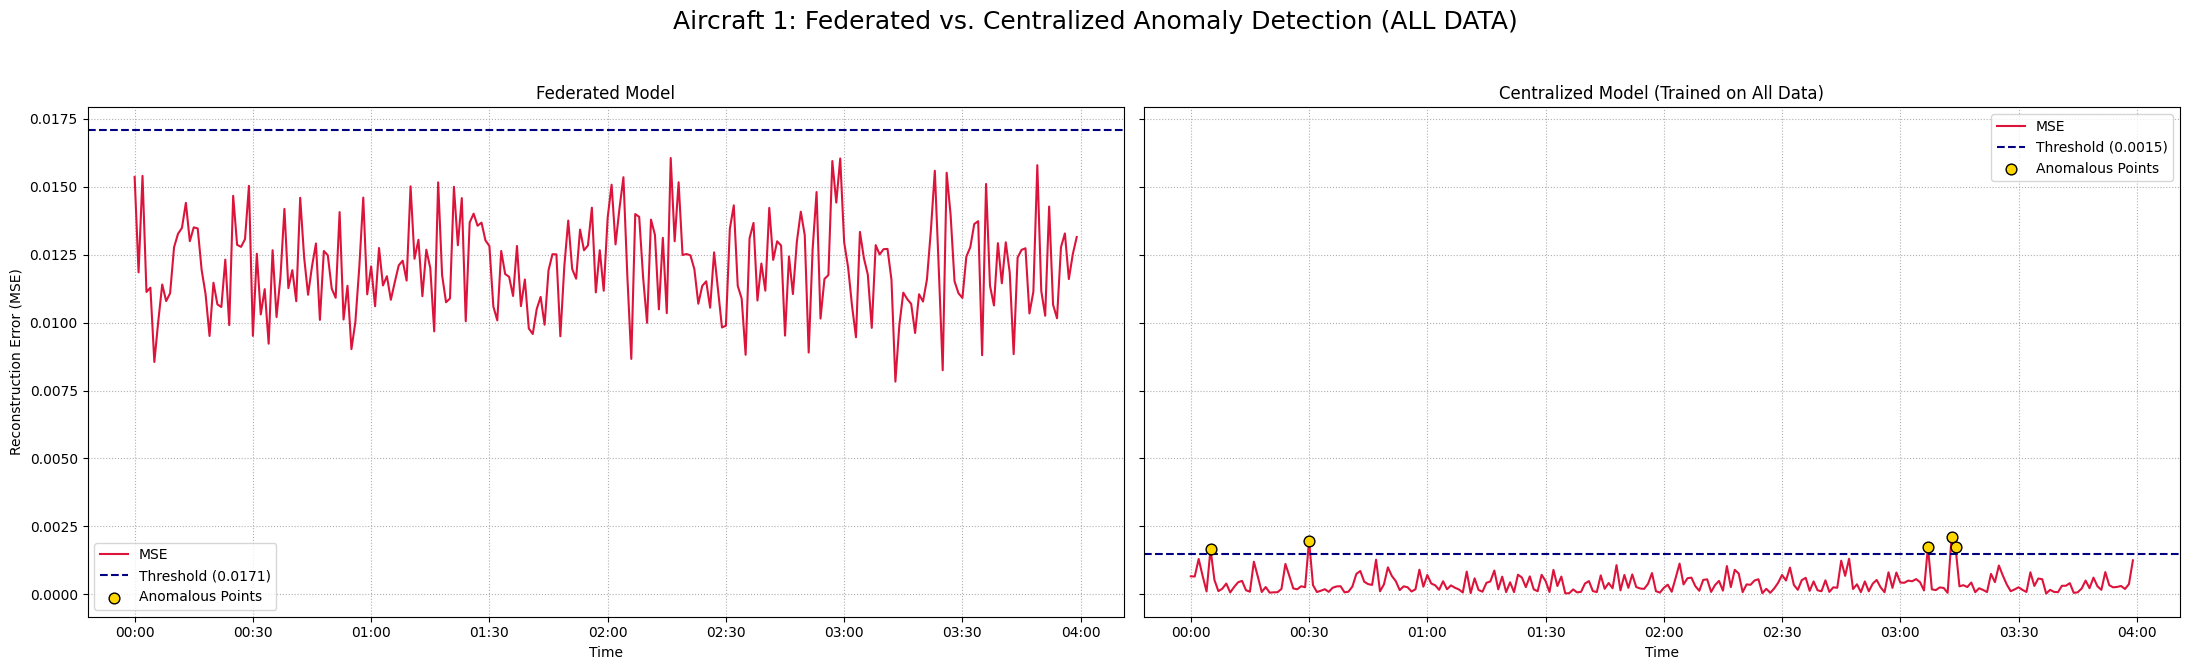

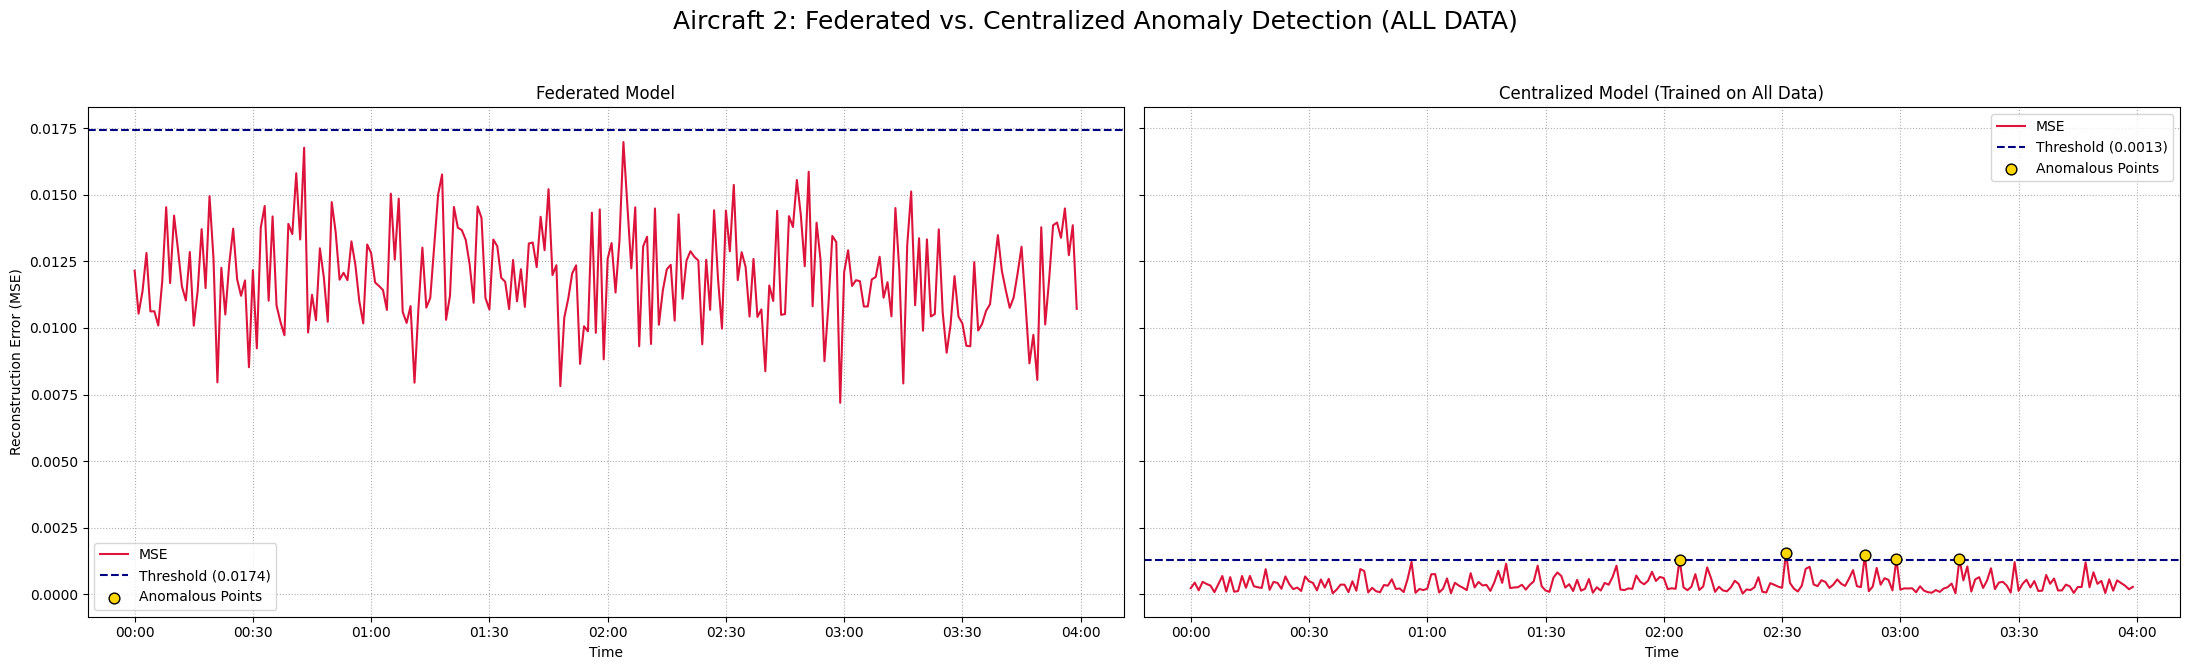

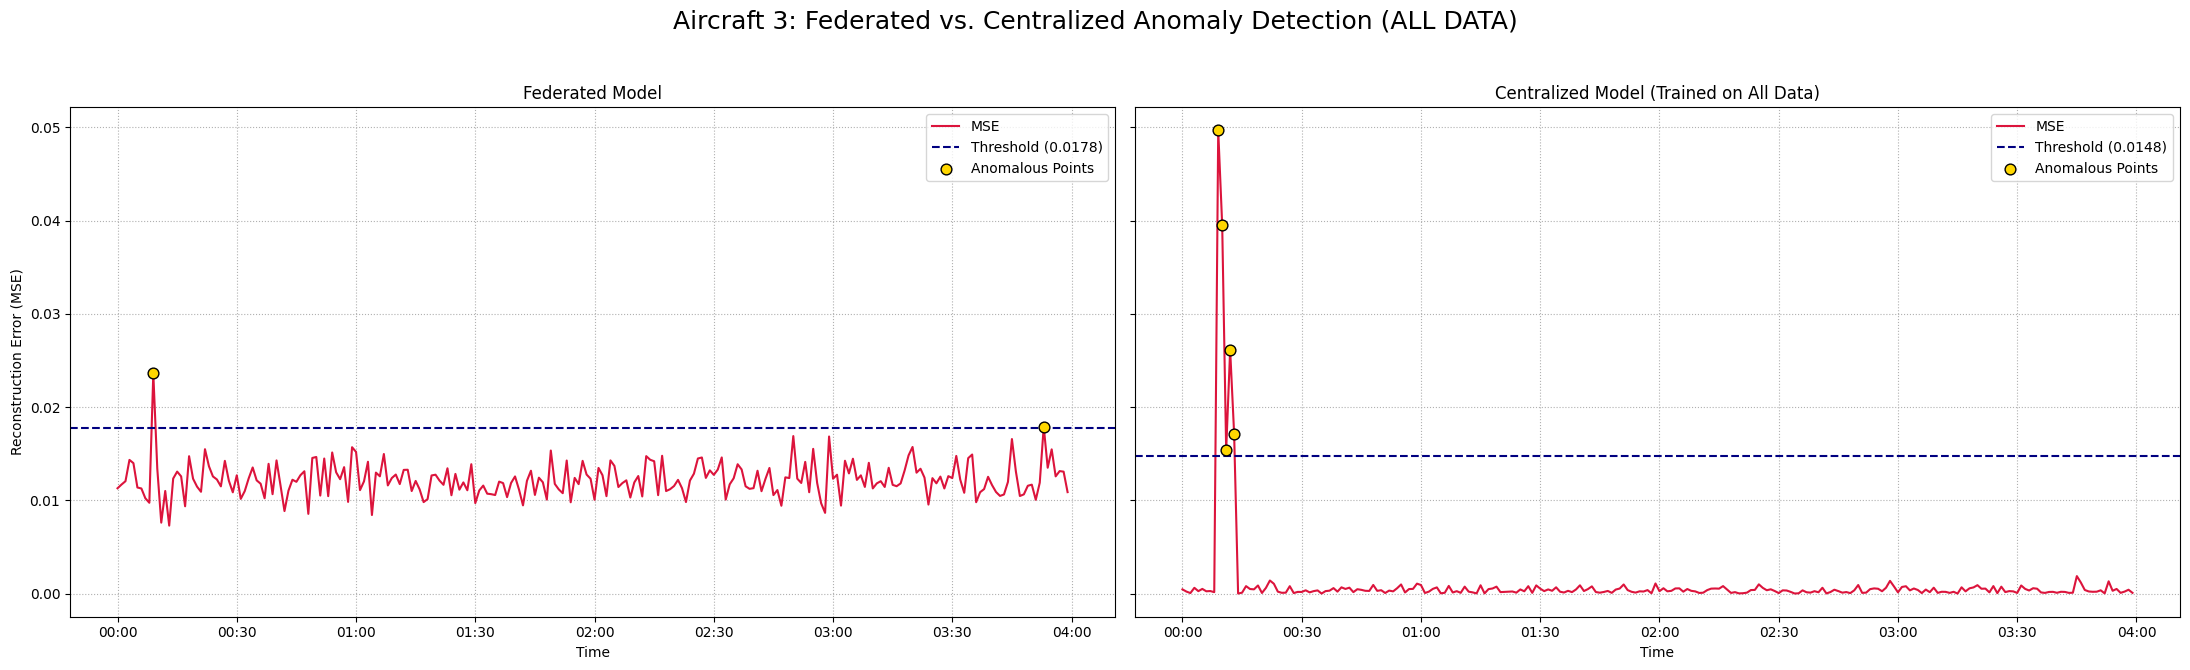

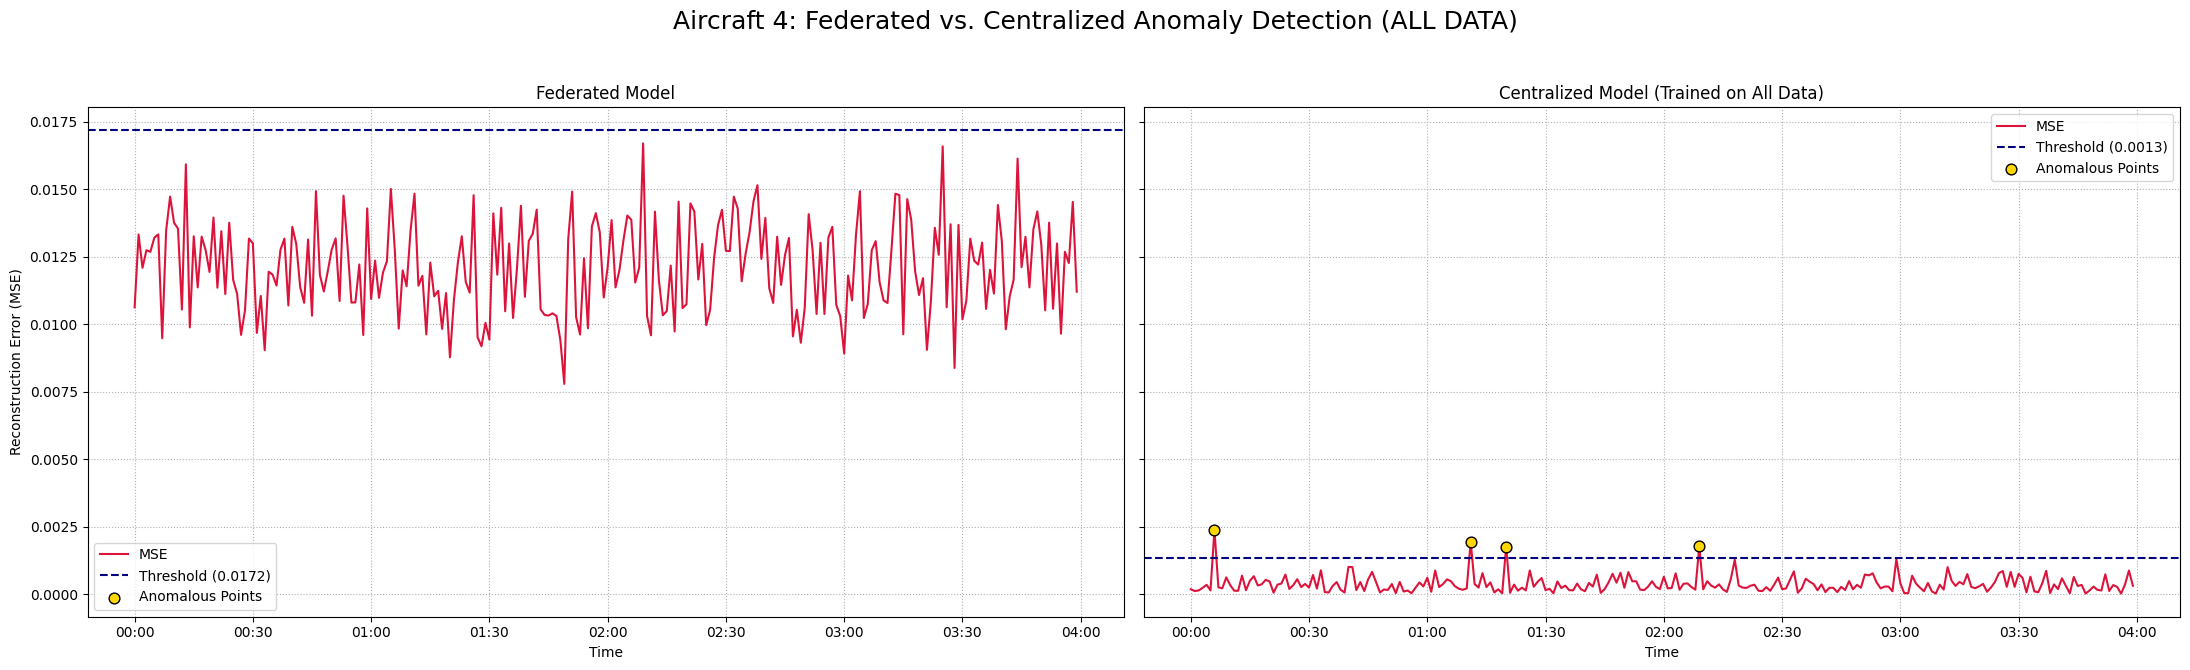

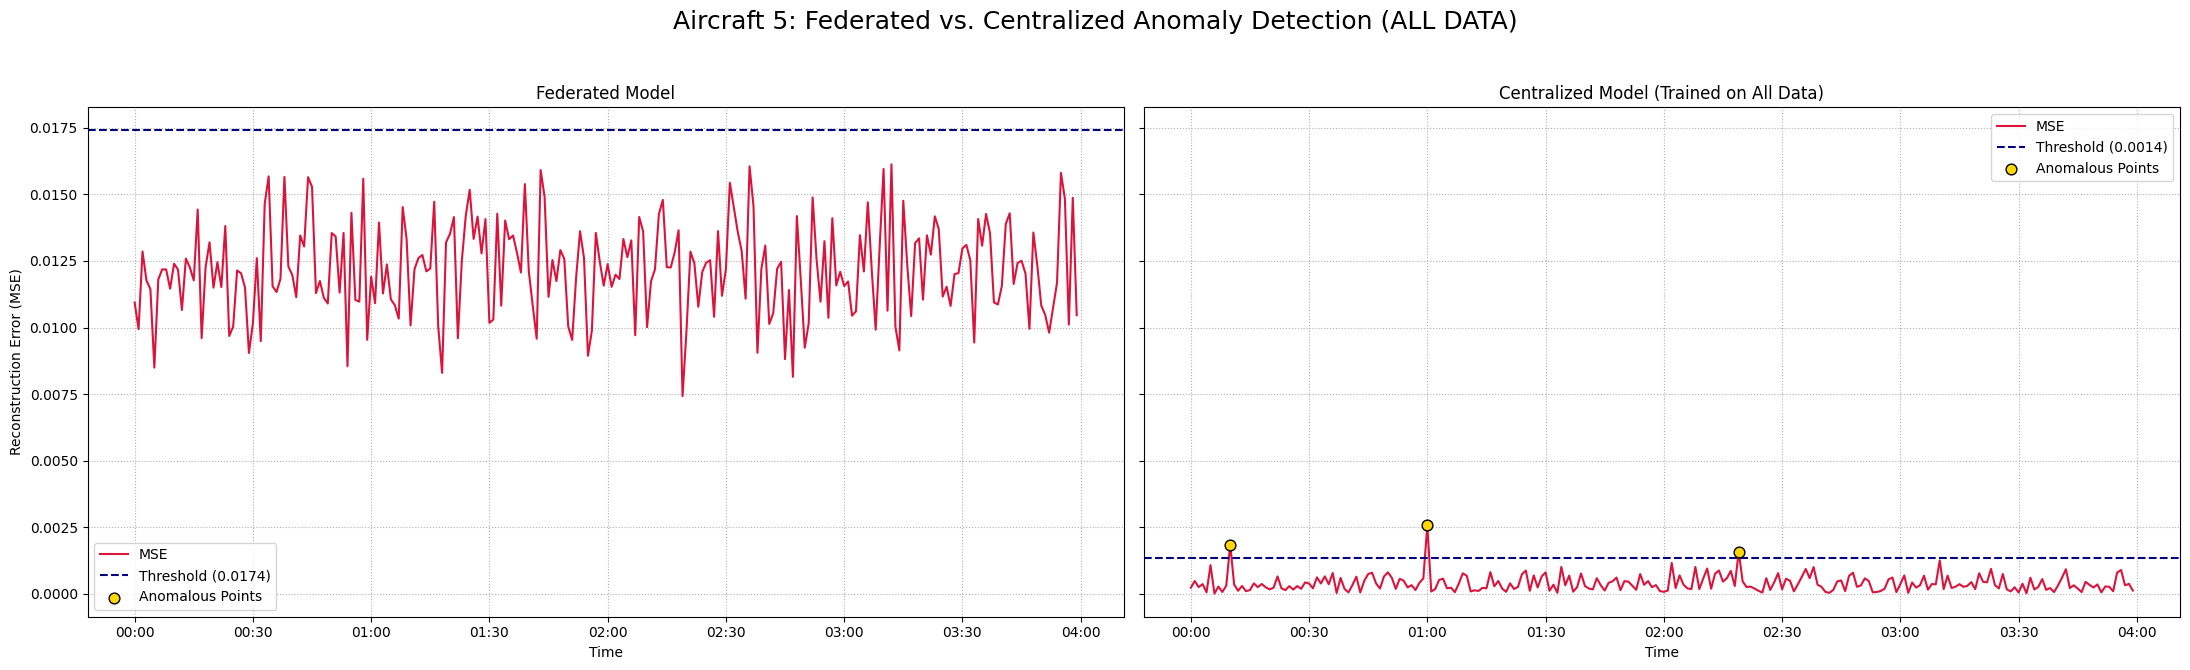

In [84]:
print("--- Generating Comparison Plots ---")

def get_errors(model, data_tensor):
    with torch.no_grad():
        model.eval()
        reconstructed = model(data_tensor)
        return torch.mean((data_tensor - reconstructed)**2, dim=1).numpy()

for i, file_path in enumerate(file_paths):
    client_id = i + 1
    client_df = pd.read_csv(file_path)
    timestamps = pd.to_datetime(client_df['timestamp'])
    # Scale data using fixed ranges (same as training)
    scaler = get_aircraft_scaler(include_anomalies=True)
    client_tensor = torch.tensor(scaler.transform(client_df[DATA_CONFIG['sensor_names']]), dtype=torch.float32)
    fed_errors = get_errors(federated_model, client_tensor)
    fed_threshold = np.mean(fed_errors) + 3 * np.std(fed_errors)
    fed_anomalies = fed_errors > fed_threshold
    cen_errors = get_errors(centralized_model, client_tensor)
    cen_threshold = np.mean(cen_errors) + 3 * np.std(cen_errors)
    cen_anomalies = cen_errors > cen_threshold
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 7), sharey=True)
    fig.suptitle(f'Aircraft {client_id}: Federated vs. Centralized Anomaly Detection (ALL DATA)', fontsize=18)
    ax1.plot(timestamps, fed_errors, label='MSE', color='crimson')
    ax1.axhline(fed_threshold, color='navy', linestyle='--', label=f'Threshold ({fed_threshold:.4f})')
    ax1.scatter(timestamps[fed_anomalies], fed_errors[fed_anomalies], s=60, color='gold', edgecolor='black', label='Anomalous Points', zorder=5)
    ax1.set_title('Federated Model')
    ax1.set_ylabel("Reconstruction Error (MSE)"); ax1.set_xlabel("Time")
    ax1.grid(True, which='both', linestyle=':'); ax1.legend()
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax2.plot(timestamps, cen_errors, label='MSE', color='crimson')
    ax2.axhline(cen_threshold, color='navy', linestyle='--', label=f'Threshold ({cen_threshold:.4f})')
    ax2.scatter(timestamps[cen_anomalies], cen_errors[cen_anomalies], s=60, color='gold', edgecolor='black', label='Anomalous Points', zorder=5)
    ax2.set_title('Centralized Model (Trained on All Data)')
    ax2.set_xlabel("Time")
    ax2.grid(True, which='both', linestyle=':'); ax2.legend()
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

In [85]:
print("\n--- Model Performance Statistics ---")

centralized_stats = []
federated_stats = []

# Ensure models are in evaluation mode
centralized_model.eval()
federated_model.eval()

# Use the same globally-fitted scaler for a fair comparison
# This 'scaler' object was fitted on the combined normal data during centralized training
global_scaler = scaler

with torch.no_grad():
    for i, file_path in enumerate(file_paths):
        client_id = i + 1
        df = pd.read_csv(file_path)
        sensor_data = df[DATA_CONFIG['sensor_names']]
        n_points = len(sensor_data)
        
        # Scale data using the single global scaler
        # Scale data using fixed ranges
        scaler = get_aircraft_scaler(include_anomalies=False)
        scaled_data = scaler.transform(sensor_data)
        data_tensor = torch.tensor(scaled_data, dtype=torch.float32)
        
        # --- Centralized Model Evaluation ---
        reconstructed_centralized = centralized_model(data_tensor)
        # Calculate per-point MSE loss
        mse_centralized = torch.mean((data_tensor - reconstructed_centralized)**2, dim=1)
        centralized_stats.append({
            'client_id': client_id,
            'status': 'Anomalous' if "anomalous" in file_path else 'Normal',
            'mean_mse': mse_centralized.mean().item(),
            'max_mse': mse_centralized.max().item(),
            'std_mse': mse_centralized.std().item(),
            'n_points': n_points
        })
        
        # --- Federated Model Evaluation ---
        reconstructed_federated = federated_model(data_tensor)
        # Calculate per-point MSE loss
        mse_federated = torch.mean((data_tensor - reconstructed_federated)**2, dim=1)
        federated_stats.append({
            'client_id': client_id,
            'status': 'Anomalous' if "anomalous" in file_path else 'Normal',
            'mean_mse': mse_federated.mean().item(),
            'max_mse': mse_federated.max().item(),
            'std_mse': mse_federated.std().item(),
            'n_points': n_points
        })

# Create DataFrames for a clean display
centralized_df = pd.DataFrame(centralized_stats).set_index('client_id')
federated_df = pd.DataFrame(federated_stats).set_index('client_id')

# Set pandas display options for better readability
pd.set_option('display.float_format', '{:.6f}'.format)

print("\n--- Centralized Model Performance ---")
display(centralized_df[['status', 'mean_mse', 'max_mse', 'std_mse', 'n_points']])

print("\n--- Federated Model Performance ---")
display(federated_df[['status', 'mean_mse', 'max_mse', 'std_mse', 'n_points']])


--- Model Performance Statistics ---

--- Centralized Model Performance ---


,status,mean_mse,max_mse,std_mse,n_points
client_id,,,,,
1,Normal,0.013865,0.023169,0.003035,240
2,Normal,0.013802,0.024293,0.003197,240
3,Anomalous,0.015717,0.173986,0.015868,240
4,Normal,0.013574,0.023504,0.002781,240
5,Normal,0.013697,0.023125,0.002885,240



--- Federated Model Performance ---


,status,mean_mse,max_mse,std_mse,n_points
client_id,,,,,
1,Normal,0.003219,0.004935,0.000482,240
2,Normal,0.003222,0.004496,0.000526,240
3,Anomalous,0.004316,0.105460,0.008639,240
4,Normal,0.003188,0.004779,0.000504,240
5,Normal,0.003216,0.004635,0.000499,240



--- Visualizing Performance Statistics ---


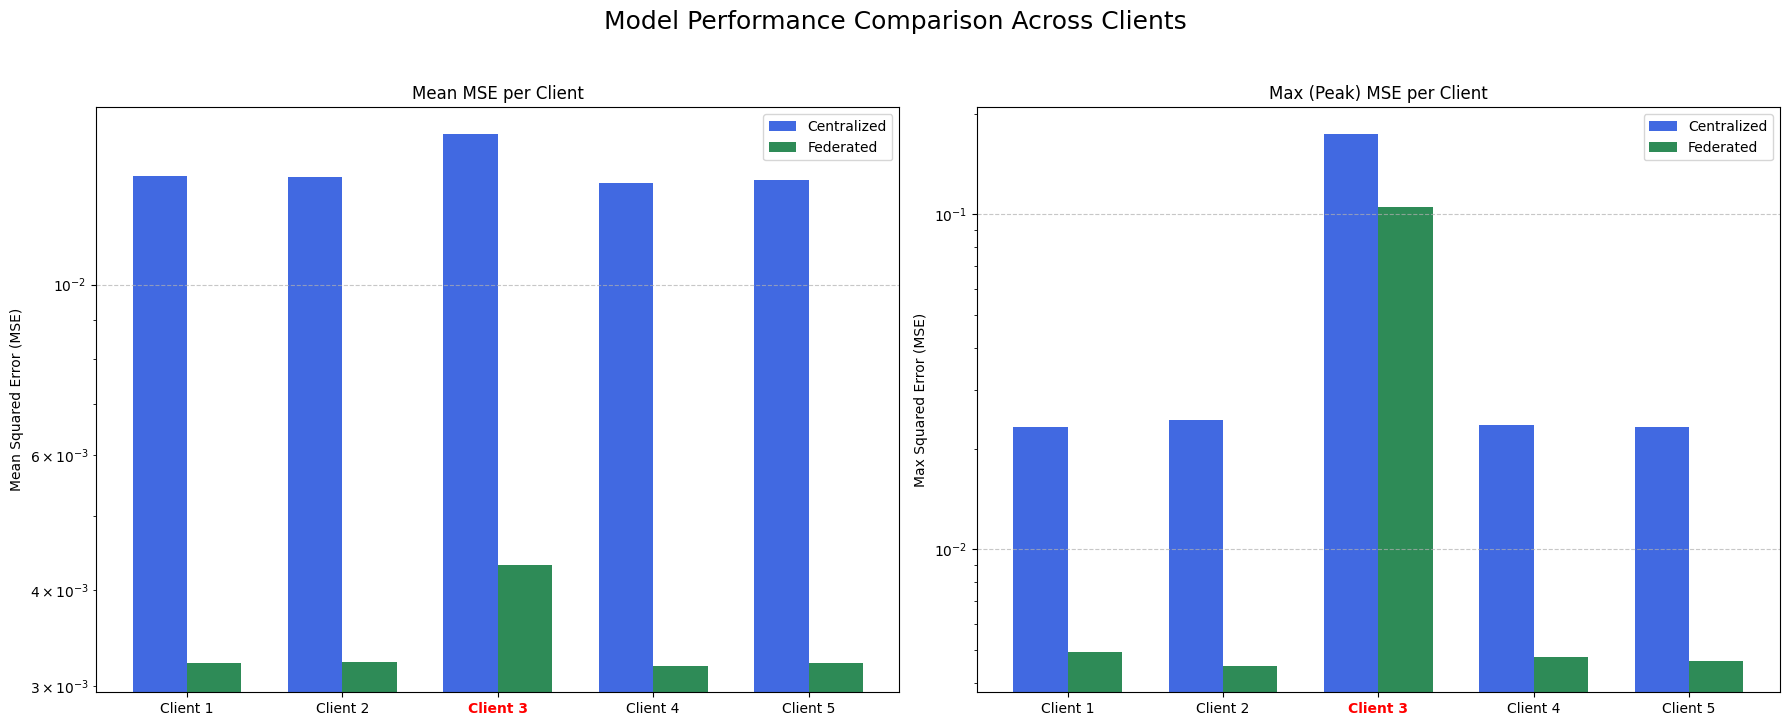

In [86]:
print("\n--- Visualizing Performance Statistics ---")

# Create a figure for the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Model Performance Comparison Across Clients', fontsize=18, y=1.03)

# --- Bar Chart for Mean MSE ---
bar_width = 0.35
client_ids = centralized_df.index
x = np.arange(len(client_ids))

rects1 = ax1.bar(x - bar_width/2, centralized_df['mean_mse'], bar_width, label='Centralized', color='royalblue')
rects2 = ax1.bar(x + bar_width/2, federated_df['mean_mse'], bar_width, label='Federated', color='seagreen')

ax1.set_ylabel('Mean Squared Error (MSE)')
ax1.set_title('Mean MSE per Client')
ax1.set_xticks(x)
ax1.set_xticklabels([f'Client {id}' for id in client_ids])
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.set_yscale('log') # Use log scale for better visibility

# --- Bar Chart for Max MSE ---
rects3 = ax2.bar(x - bar_width/2, centralized_df['max_mse'], bar_width, label='Centralized', color='royalblue')
rects4 = ax2.bar(x + bar_width/2, federated_df['max_mse'], bar_width, label='Federated', color='seagreen')

ax2.set_ylabel('Max Squared Error (MSE)')
ax2.set_title('Max (Peak) MSE per Client')
ax2.set_xticks(x)
ax2.set_xticklabels([f'Client {id}' for id in client_ids])
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.set_yscale('log') # Log scale is useful for comparing large spikes

# Add a visual indicator for the anomalous client
for ax in [ax1, ax2]:
    for i, client_id in enumerate(client_ids):
        # Find which client is anomalous from the dataframe status
        if centralized_df.loc[client_id, 'status'] == 'Anomalous':
            ax.get_xticklabels()[i].set_color('red')
            ax.get_xticklabels()[i].set_weight('bold')

fig.tight_layout()
plt.show()

In [87]:
print("\n--- Simple Epoch Comparison: Federated vs Centralized ---")

# Test different epoch configurations
epochs_to_test = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200]

# Store results
results = []

print("Testing different epoch configurations...")

for epochs in epochs_to_test:
    print(f"\n--- Testing {epochs} epochs ---")
    
    # Train centralized model
    centralized_test = Autoencoder(
        input_dim=MODEL_CONFIG['input_dim'],
        hidden_dim=MODEL_CONFIG['hidden_dim'],
        latent_dim=MODEL_CONFIG['latent_dim']
    )
    centralized_test.train_on_tensor(train_tensor, num_epochs=epochs, lr=TRAINING_CONFIG['learning_rate'])
    
    # Train federated model
    test_clients = [
        FederatedClient(client_id=i + 1, file_path=file_paths[i])
        for i in range(DATA_CONFIG['num_aircraft'])
    ]
    test_base_model = Autoencoder(
        input_dim=MODEL_CONFIG['input_dim'],
        hidden_dim=MODEL_CONFIG['hidden_dim'],
        latent_dim=MODEL_CONFIG['latent_dim']
    )
    test_server = CentralizedServer(clients=test_clients, model=test_base_model)
    test_server.train(rounds=10, local_epochs=epochs//10, lr=TRAINING_CONFIG['learning_rate'])
    
    # Calculate MSE for both models
    centralized_test.eval()
    test_server.global_model.eval()
    
    with torch.no_grad():
        # Centralized MSE
        cen_reconstructed = centralized_test(train_tensor)
        cen_mse = nn.MSELoss()(cen_reconstructed, train_tensor).item()
        
        # Federated MSE
        fed_reconstructed = test_server.global_model(train_tensor)
        fed_mse = nn.MSELoss()(fed_reconstructed, train_tensor).item()
    
    results.append({
        'epochs': epochs,
        'centralized_mse': cen_mse,
        'federated_mse': fed_mse,
        'federated_better': fed_mse < cen_mse
    })
    
    print(f"   Centralized MSE: {cen_mse:.6f}")
    print(f"   Federated MSE: {fed_mse:.6f}")
    print(f"   Federated better: {fed_mse < cen_mse}")


--- Simple Epoch Comparison: Federated vs Centralized ---
Testing different epoch configurations...

--- Testing 10 epochs ---
Starting training...
  Epoch [10/10], Loss: 0.000681

ROUND 1/10
  -> Training Client 1...
  -> Training Client 2...
  -> Training Client 3...
  -> Training Client 4...
  -> Training Client 5...

ROUND 2/10
  -> Training Client 1...
  -> Training Client 2...
  -> Training Client 3...
  -> Training Client 4...
  -> Training Client 5...

ROUND 3/10
  -> Training Client 1...
  -> Training Client 2...
  -> Training Client 3...
  -> Training Client 4...
  -> Training Client 5...

ROUND 4/10
  -> Training Client 1...
  -> Training Client 2...
  -> Training Client 3...
  -> Training Client 4...
  -> Training Client 5...

ROUND 5/10
  -> Training Client 1...
  -> Training Client 2...
  -> Training Client 3...
  -> Training Client 4...
  -> Training Client 5...

ROUND 6/10
  -> Training Client 1...
  -> Training Client 2...
  -> Training Client 3...
  -> Training Clien

In [88]:
# Create results DataFrame
results_df = pd.DataFrame(results)

print("\n--- Results Summary ---")
display(results_df)

# Find crossover point
crossover_found = False
for i, row in results_df.iterrows():
    if row['federated_better']:
        print(f"\n🎯 CROSSOVER POINT FOUND!")
        print(f"   Federated Learning becomes better at {row['epochs']} epochs")
        print(f"   Centralized MSE: {row['centralized_mse']:.6f}")
        print(f"   Federated MSE: {row['federated_mse']:.6f}")
        crossover_found = True
        break

if not crossover_found:
    print("\n❌ No crossover point found in tested range")


--- Results Summary ---


,epochs,centralized_mse,federated_mse,federated_better
0,10,0.000867,0.031905,False
1,20,0.000679,0.028078,False
2,30,0.000227,0.020795,False
3,40,0.000172,0.005541,False
4,50,0.000217,0.018484,False
5,60,0.000030,0.002170,False
6,70,0.000199,0.000152,True
7,80,0.000027,0.000158,False
8,90,0.000025,0.000101,False
9,100,0.000024,0.000079,False



🎯 CROSSOVER POINT FOUND!
   Federated Learning becomes better at 70 epochs
   Centralized MSE: 0.000199
   Federated MSE: 0.000152


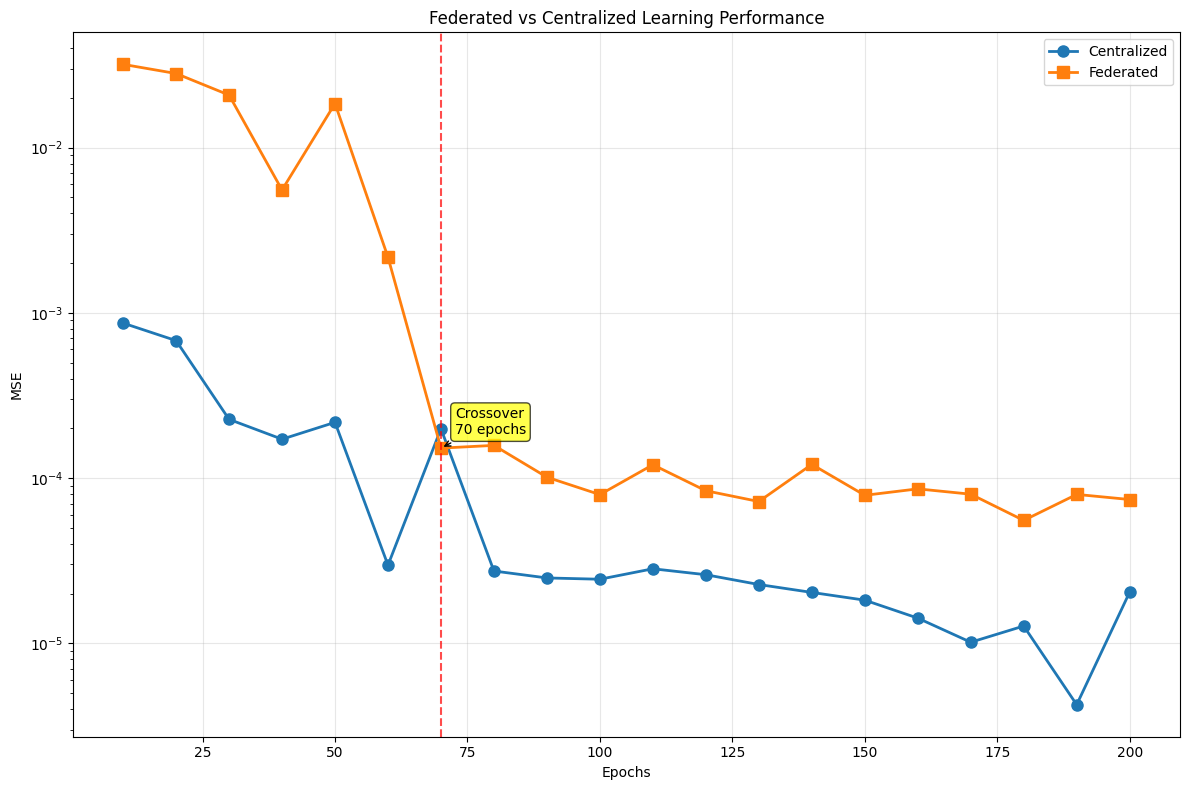

In [89]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(results_df['epochs'], results_df['centralized_mse'], 
         marker='o', label='Centralized', linewidth=2, markersize=8)
plt.plot(results_df['epochs'], results_df['federated_mse'], 
         marker='s', label='Federated', linewidth=2, markersize=8)

plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('Federated vs Centralized Learning Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Highlight crossover point
if crossover_found:
    for i, row in results_df.iterrows():
        if row['federated_better']:
            plt.axvline(x=row['epochs'], color='red', linestyle='--', alpha=0.7, 
                       label=f'Crossover at {row["epochs"]} epochs')
            plt.annotate(f'Crossover\n{row["epochs"]} epochs', 
                        xy=(row['epochs'], row['federated_mse']),
                        xytext=(10, 10), textcoords='offset points',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                        arrowprops=dict(arrowstyle='->'))
            break

plt.tight_layout()
plt.show()